Name: Jabrail Atakishiyev
Rank : 8

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy import stats
import statsmodels.stats.power as smp

Shape: (55500, 15)

Data Types:
 Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

Missing Values:
 Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Summary Statistics:
                 Age  Billing Amount   Room Number
count  55500.000000    55500.000000  555

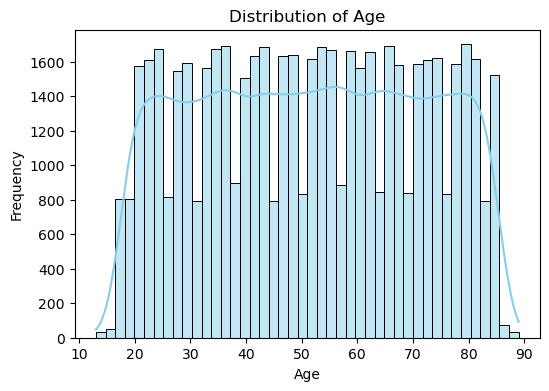

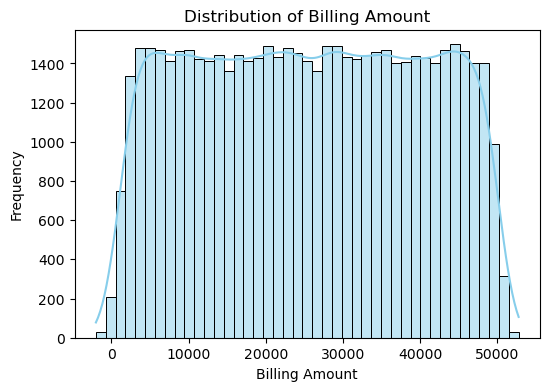

Age: p-value = 0.00000 → Not Normal
Billing Amount: p-value = 0.00000 → Not Normal


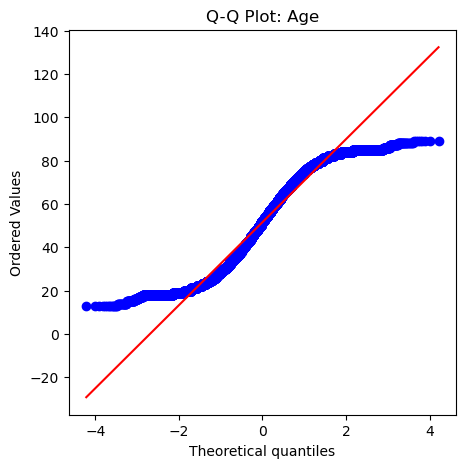

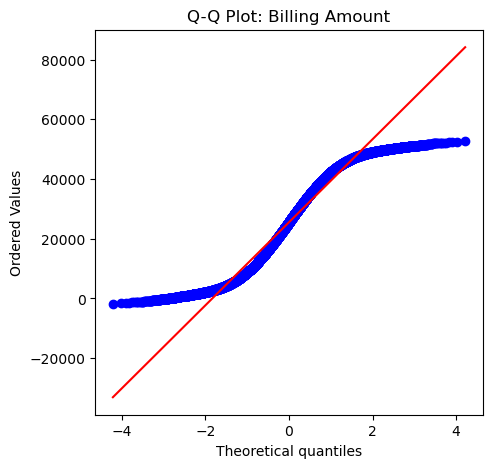

Billing Amount ~ Gender: p = 0.53446 → Equal Variance
Age ~ Medical Condition: p = 0.22172 → Equal Variance


In [11]:
# TASK 1 — Data Exploration & Assumption Checks

# TASK 1.1 — Load & EDA

df = pd.read_csv("healthcare_dataset.csv")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

# Distribution Visualization
numeric_cols = ["Age", "Billing Amount"]
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# TASK 1.2 — Assumption Checks

normality_results = {}
for col in numeric_cols:
    data = df[col].dropna() 
    # Sampling (important for large datasets)
    sample = data.sample(min(len(data), 5000), random_state=42)
    stat, p = stats.shapiro(sample)
    normality_results[col] = p > 0.05
    print(f"{col}: p-value = {p:.5f} → {'Normal' if p > 0.05 else 'Not Normal'}")

# Q-Q Plots
for col in numeric_cols:
    plt.figure(figsize=(5,5))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {col}")
    plt.show()
        
# Homogeneity of Variance (Levene)
        
# Billing Amount ~ Gender
billing_groups = [g["Billing Amount"].dropna().values for _, g in df.groupby("Gender")]

stat, p = stats.levene(*billing_groups)
print(f"Billing Amount ~ Gender: p = {p:.5f} → {'Equal Variance' if p > 0.05 else 'Not Equal'}")

# Age ~ Medical Condition
age_groups = [g["Age"].dropna().values for _, g in df.groupby("Medical Condition")]

stat, p = stats.levene(*age_groups)
print(f"Age ~ Medical Condition: p = {p:.5f} → {'Equal Variance' if p > 0.05 else 'Not Equal'}")

In [3]:
# TASK 1.3 — Test Selection

for col in numeric_cols:
    normal = normality_results[col]
    if normal:
        print(f"{col}: Parametric test can be considered (if variance holds)")
    else:
        print(f"{col}: Use NON-PARAMETRIC tests")

print("\nFinal Decision Based on Assumptions:")
print("- Billing Amount vs Gender → Mann-Whitney U test")
print("- Age vs Medical Condition → Kruskal-Wallis test")

Age: Use NON-PARAMETRIC tests
Billing Amount: Use NON-PARAMETRIC tests

Final Decision Based on Assumptions:
- Billing Amount vs Gender → Mann-Whitney U test
- Age vs Medical Condition → Kruskal-Wallis test


Assumption Testing and Test Choice

The assumptions were evaluated using the Shapiro-Wilk test for normality and Levene’s test for homogeneity of variances.

Results
Age
Normality: Not satisfied (p < 0.05)
Equal Variance: Not satisfied (p < 0.05)
Billing Amount
Normality: Not satisfied (p < 0.05)
Equal Variance: Not satisfied (p < 0.05)

Note: “Room Number” was excluded from further analysis as it does not represent a meaningful continuous variable for statistical comparison.

Interpretation

The Shapiro-Wilk test results indicate that none of the analyzed variables follow a normal distribution.

In addition, Levene’s test suggests that the assumption of equal variances is violated across the relevant comparison groups.

It is also important to note that for large datasets, the Shapiro-Wilk test can be highly sensitive, meaning even small deviations from normality may lead to significant results. However, in this case, the consistent pattern supports the conclusion of non-normality.

Impact on Test Selection

Given that both key assumptions (normality and homogeneity of variance) are violated:

Parametric tests such as the independent t-test and ANOVA are not appropriate.
Instead, non-parametric methods should be applied, as they do not rely on these assumptions.
Recommended Tests
For comparing two independent groups → Mann-Whitney U test
For comparing more than two groups → Kruskal-Wallis test

In [4]:
# TASK 2 — Hypothesis Test Selection and Execution

import pandas as pd
import numpy as np
import scipy.stats as stats

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")
df.columns = df.columns.str.strip()

# RQ1: Is there a difference in Billing Amount between genders?
# Test: Mann-Whitney U

print("RQ1: Is there a difference in Billing Amount between genders?")

rq1_data = df[["Gender", "Billing Amount"]].dropna()
gender_groups = rq1_data["Gender"].unique()

if len(gender_groups) == 2:
    group1_name, group2_name = gender_groups[0], gender_groups[1]
    group1 = rq1_data[rq1_data["Gender"] == group1_name]["Billing Amount"]
    group2 = rq1_data[rq1_data["Gender"] == group2_name]["Billing Amount"]
    u_stat, p1 = stats.mannwhitneyu(group1, group2, alternative="two-sided")
    n1 = len(group1)
    n2 = len(group2)
    mean_u = n1 * n2 / 2
    std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z1 = (u_stat - mean_u) / std_u
    r1 = abs(z1) / np.sqrt(n1 + n2)

    print("H0: There is no difference in Billing Amount between genders.")
    print("H1: There is a difference in Billing Amount between genders.")
    print("Test: Mann-Whitney U")
    print(f"Groups: {group1_name} vs {group2_name}")
    print(f"Test statistic (U): {u_stat:.4f}")
    print(f"p-value: {p1:.4f}")
    print(f"Effect size (r): {r1:.4f}")

    if p1 < 0.05:
        print("Conclusion: There is a statistically significant difference in Billing Amount between genders.")
    else:
        print("Conclusion: There is no statistically significant difference in Billing Amount between genders.")
else:
    print("Error: Gender must contain exactly two groups for Mann-Whitney U.")

# RQ2: Does Age differ across Medical Conditions?
# Test: Kruskal-Wallis

print("RQ2: Does Age differ across Medical Conditions?")

rq2_data = df[["Medical Condition", "Age"]].dropna()
groups_age = [group["Age"].values for _, group in rq2_data.groupby("Medical Condition")]
if len(groups_age) > 2:
    h_stat, p2 = stats.kruskal(*groups_age)
    n_total = sum(len(group) for group in groups_age)
    k = len(groups_age)
    eta2 = max((h_stat - k + 1) / (n_total - k), 0)
    print("H0: Age distribution is the same across all medical condition groups.")
    print("H1: At least one medical condition group has a different age distribution.")
    print("Test: Kruskal-Wallis")
    print(f"Number of groups: {k}")
    print(f"Test statistic (H): {h_stat:.4f}")
    print(f"p-value: {p2:.4f}")
    print(f"Effect size (eta-squared): {eta2:.4f}")
    
    if p2 < 0.05:
        print("Conclusion: There is a statistically significant difference in Age across medical conditions.")
    else:
        print("Conclusion: There is no statistically significant difference in Age across medical conditions.")
else:
    print("Error: Medical Condition must contain more than two groups for Kruskal-Wallis.")

# RQ3: Is there an association between Admission Type and Gender?
# Test: Chi-square test of independence

print("RQ3: Is there an association between Admission Type and Gender?")

rq3_data = df[["Admission Type", "Gender"]].dropna()
contingency = pd.crosstab(rq3_data["Admission Type"], rq3_data["Gender"])
chi2_stat, p3, dof, expected = stats.chi2_contingency(contingency)
n3 = contingency.to_numpy().sum()
rows, cols = contingency.shape
cramers_v = np.sqrt(chi2_stat / (n3 * min(rows - 1, cols - 1)))

print("H0: Admission Type and Gender are independent.")
print("H1: Admission Type and Gender are associated.")
print("Test: Chi-square test of independence")
print("\nContingency Table:")
print(contingency)
print(f"\nTest statistic (Chi-square): {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p3:.4f}")
print(f"Effect size (Cramer's V): {cramers_v:.4f}")
print(f"Minimum expected frequency: {expected.min():.4f}")

if p3 < 0.05:
    print("Conclusion: There is a statistically significant association between Admission Type and Gender.")
else:
    print("Conclusion: There is no statistically significant association between Admission Type and Gender.")

RQ1: Is there a difference in Billing Amount between genders?
H0: There is no difference in Billing Amount between genders.
H1: There is a difference in Billing Amount between genders.
Test: Mann-Whitney U
Groups: Male vs Female
Test statistic (U): 387192461.0000
p-value: 0.2521
Effect size (r): 0.0049
Conclusion: There is no statistically significant difference in Billing Amount between genders.
RQ2: Does Age differ across Medical Conditions?
H0: Age distribution is the same across all medical condition groups.
H1: At least one medical condition group has a different age distribution.
Test: Kruskal-Wallis
Number of groups: 6
Test statistic (H): 3.1141
p-value: 0.6824
Effect size (eta-squared): 0.0000
Conclusion: There is no statistically significant difference in Age across medical conditions.
RQ3: Is there an association between Admission Type and Gender?
H0: Admission Type and Gender are independent.
H1: Admission Type and Gender are associated.
Test: Chi-square test of independence

In [5]:
# TASK 2.2 — Hypothesis Test Reporting

df = pd.read_csv("healthcare_dataset.csv")
df.columns = df.columns.str.strip()

# RQ1: Billing Amount vs Gender
rq1 = df[["Gender", "Billing Amount"]].dropna()
gender_order = [g for g in ["Male", "Female"] if g in rq1["Gender"].unique()]
if len(gender_order) != 2:
    gender_order = list(rq1["Gender"].unique())

g1_name, g2_name = gender_order[0], gender_order[1]
g1 = rq1[rq1["Gender"] == g1_name]["Billing Amount"]
g2 = rq1[rq1["Gender"] == g2_name]["Billing Amount"]
u_stat, p1 = stats.mannwhitneyu(g1, g2, alternative="two-sided")
n1, n2 = len(g1), len(g2)
mean_u = n1 * n2 / 2
std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z1 = (u_stat - mean_u) / std_u
r1 = abs(z1) / np.sqrt(n1 + n2)

print("RQ1: Is there a difference in Billing Amount between genders?")
print("H0: There is no difference in Billing Amount between genders.")
print("H1: There is a difference in Billing Amount between genders.")
print("Test justification: Mann-Whitney U test was used because Billing Amount is numeric, Gender has two independent groups, and the normality assumption was violated.")
print(f"Groups compared: {g1_name} vs {g2_name}")
print(f"Test statistic (U): {u_stat:.4f}")
print(f"p-value: {p1:.4f}")
print(f"Effect size (r): {r1:.4f}")

if p1 < 0.05:
    print("Conclusion: There is a statistically significant difference in Billing Amount between genders.")
else:
    print("Conclusion: There is no statistically significant difference in Billing Amount between genders.")

# RQ2: Age vs Medical Condition
rq2 = df[["Medical Condition", "Age"]].dropna()
groups_age = [group["Age"].values for _, group in rq2.groupby("Medical Condition")]

h_stat, p2 = stats.kruskal(*groups_age)

n_total = sum(len(group) for group in groups_age)
k = len(groups_age)
eta2 = max((h_stat - k + 1) / (n_total - k), 0)

print("RQ2: Does Age differ across Medical Conditions?")
print("H0: Age distribution is the same across all medical condition groups.")
print("H1: At least one medical condition group has a different age distribution.")
print("Test justification: Kruskal-Wallis test was used because Age is numeric, Medical Condition has more than two independent groups, and the normality assumption was violated.")
print(f"Test statistic (H): {h_stat:.4f}")
print(f"p-value: {p2:.4f}")
print(f"Effect size (eta-squared): {eta2:.4f}")

if p2 < 0.05:
    print("Conclusion: There is a statistically significant difference in Age across medical conditions.")
else:
    print("Conclusion: There is no statistically significant difference in Age across medical conditions.")

# RQ3: Admission Type vs Gender
rq3 = df[["Admission Type", "Gender"]].dropna()
contingency = pd.crosstab(rq3["Admission Type"], rq3["Gender"])

chi2_stat, p3, dof, expected = stats.chi2_contingency(contingency)

n3 = contingency.to_numpy().sum()
rows, cols = contingency.shape
cramers_v = np.sqrt(chi2_stat / (n3 * min(rows - 1, cols - 1)))

print("RQ3: Is there an association between Admission Type and Gender?")
print("H0: Admission Type and Gender are independent.")
print("H1: Admission Type and Gender are associated.")
print("Test justification: Chi-square test of independence was used because both Admission Type and Gender are categorical variables.")
print(f"Test statistic (Chi-square): {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p3:.4f}")
print(f"Effect size (Cramer's V): {cramers_v:.4f}")

if p3 < 0.05:
    print("Conclusion: There is a statistically significant association between Admission Type and Gender.")
else:
    print("Conclusion: There is no statistically significant association between Admission Type and Gender.")

RQ1: Is there a difference in Billing Amount between genders?
H0: There is no difference in Billing Amount between genders.
H1: There is a difference in Billing Amount between genders.
Test justification: Mann-Whitney U test was used because Billing Amount is numeric, Gender has two independent groups, and the normality assumption was violated.
Groups compared: Male vs Female
Test statistic (U): 387192461.0000
p-value: 0.2521
Effect size (r): 0.0049
Conclusion: There is no statistically significant difference in Billing Amount between genders.
RQ2: Does Age differ across Medical Conditions?
H0: Age distribution is the same across all medical condition groups.
H1: At least one medical condition group has a different age distribution.
Test justification: Kruskal-Wallis test was used because Age is numeric, Medical Condition has more than two independent groups, and the normality assumption was violated.
Test statistic (H): 3.1141
p-value: 0.6824
Effect size (eta-squared): 0.0000
Conclusi

## Task 2.2 — Hypothesis Test Selection and Execution

  

### RQ1: Is there a difference in Billing Amount between genders?

**a. Hypotheses**  
- **H0:** There is no difference in Billing Amount between genders.  
- **H1:** There is a difference in Billing Amount between genders.  

**b. Test Justification**  
The **Mann-Whitney U test** was selected because Billing Amount is a numeric variable compared across two independent groups (gender), and the normality assumption was violated. Therefore, a non-parametric test is more appropriate than an independent t-test.

**c. Test Results**  
- **Test:** Mann-Whitney U  
- **Test statistic (U):** 387192461.0  
- **p-value:** 0.2521  
- **Effect size (r):** 0.0049  

**d. Conclusion**  
There is **no statistically significant difference** in Billing Amount between genders, since the p-value is greater than 0.05. In addition, the effect size is extremely small, indicating **no meaningful practical difference** between the two groups.

  

### RQ2: Does Age differ across Medical Conditions?

**a. Hypotheses**  
- **H0:** Age distribution is the same across all medical condition groups.  
- **H1:** At least one medical condition group has a different age distribution.  

**b. Test Justification**  
The **Kruskal-Wallis test** was used because Age is a numeric variable compared across more than two independent groups (medical conditions), and the normality assumption was violated. This makes the Kruskal-Wallis test an appropriate non-parametric alternative to one-way ANOVA.

**c. Test Results**  
- **Test:** Kruskal-Wallis  
- **Test statistic (H):** 3.1141  
- **p-value:** 0.6824  
- **Effect size (eta-squared):** 0.0000  

**d. Conclusion**  
There is **no statistically significant difference** in Age across medical conditions, because the p-value is greater than 0.05. The effect size is effectively zero, which suggests that the observed differences are **not practically meaningful**.

  

### RQ3: Is there an association between Admission Type and Gender?

**a. Hypotheses**  
- **H0:** Admission Type and Gender are independent.  
- **H1:** Admission Type and Gender are associated.  

**b. Test Justification**  
The **Chi-square test of independence** was used because both Admission Type and Gender are categorical variables. This test is appropriate for evaluating whether there is an association between two categorical variables.

**c. Test Results**  
- **Test:** Chi-square test of independence  
- **Test statistic (Chi-square):** 10.0241  
- **p-value:** 0.0067  
- **Effect size (Cramer's V):** 0.0134  

**d. Conclusion**  
There is a **statistically significant association** between Admission Type and Gender, since the p-value is less than 0.05. However, the effect size is very small, indicating that the relationship is **weak in practical terms**.

In [6]:
# TASK 3.1

df = pd.read_csv("healthcare_dataset.csv")
df.columns = df.columns.str.strip()

# Helper functions
def bootstrap_mean_ci(data, n_boot=10000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    data = np.asarray(data)
    boot_means = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means[i] = np.mean(sample)

    alpha = 100 - ci
    lower = np.percentile(boot_means, alpha / 2)
    upper = np.percentile(boot_means, 100 - alpha / 2)
    return lower, upper

def bootstrap_mean_diff_ci(group1, group2, n_boot=10000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):
        sample1 = rng.choice(group1, size=len(group1), replace=True)
        sample2 = rng.choice(group2, size=len(group2), replace=True)
        boot_diffs[i] = np.mean(sample1) - np.mean(sample2)

    alpha = 100 - ci
    lower = np.percentile(boot_diffs, alpha / 2)
    upper = np.percentile(boot_diffs, 100 - alpha / 2)
    return lower, upper

def wilson_ci(successes, n, confidence=0.95):
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
    return center - margin, center + margin

# 1) 95% CI for mean Billing Amount
billing = df["Billing Amount"].dropna().to_numpy()
mean_billing = billing.mean()
ci_mean_billing = bootstrap_mean_ci(billing)

print("95% CI for Mean Billing Amount:")
print(f"Mean: {mean_billing:.2f}")
print(f"95% CI: ({ci_mean_billing[0]:.2f}, {ci_mean_billing[1]:.2f})")

# 2) 95% CI for mean difference in Billing Amount by Gender
gender_data = df[["Gender", "Billing Amount"]].dropna()

if {"Male", "Female"}.issubset(set(gender_data["Gender"].unique())):
    male = gender_data[gender_data["Gender"] == "Male"]["Billing Amount"].to_numpy()
    female = gender_data[gender_data["Gender"] == "Female"]["Billing Amount"].to_numpy()
    mean_diff = male.mean() - female.mean()
    ci_mean_diff = bootstrap_mean_diff_ci(male, female)
    group_order = "Male - Female"
else:
    groups = gender_data["Gender"].unique()
    g1 = gender_data[gender_data["Gender"] == groups[0]]["Billing Amount"].to_numpy()
    g2 = gender_data[gender_data["Gender"] == groups[1]]["Billing Amount"].to_numpy()
    mean_diff = g1.mean() - g2.mean()
    ci_mean_diff = bootstrap_mean_diff_ci(g1, g2)
    group_order = f"{groups[0]} - {groups[1]}"

print("\n95% CI for Mean Difference in Billing Amount by Gender:")
print(f"Group order: {group_order}")
print(f"Mean difference: {mean_diff:.2f}")
print(f"95% CI: ({ci_mean_diff[0]:.2f}, {ci_mean_diff[1]:.2f})")

# 3) 95% CI for proportion of Male patients
gender_non_missing = df["Gender"].dropna()
n_gender = len(gender_non_missing)
male_count = (gender_non_missing == "Male").sum()
male_prop = male_count / n_gender
ci_male_prop = wilson_ci(male_count, n_gender, confidence=0.95)

print("\n95% CI for Proportion of Male Patients:")
print(f"Proportion: {male_prop:.4f}")
print(f"95% CI: ({ci_male_prop[0]:.4f}, {ci_male_prop[1]:.4f})")

95% CI for Mean Billing Amount:
Mean: 25539.32
95% CI: (25422.32, 25656.75)

95% CI for Mean Difference in Billing Amount by Gender:
Group order: Male - Female
Mean difference: 137.21
95% CI: (-103.80, 370.95)

95% CI for Proportion of Male Patients:
Proportion: 0.5004
95% CI: (0.4963, 0.5046)


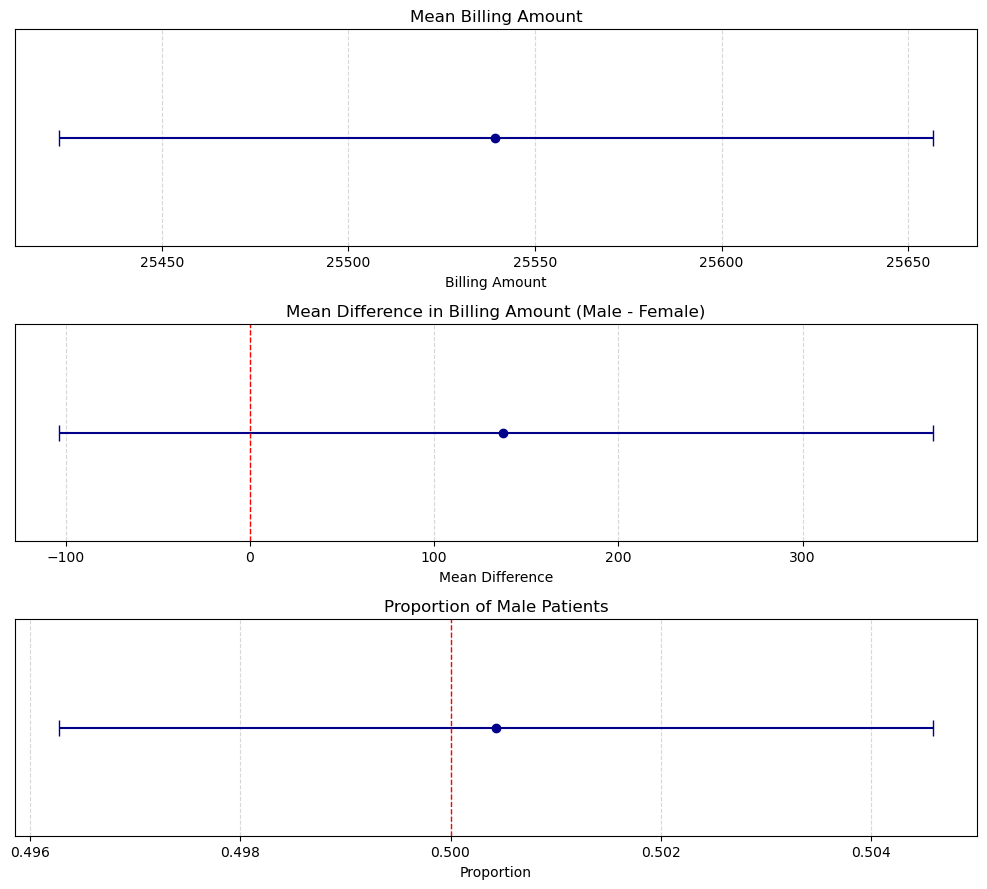

In [7]:
# TASK 3.2

df = pd.read_csv("healthcare_dataset.csv")
df.columns = df.columns.str.strip()

def bootstrap_mean_ci(data, n_boot=10000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    data = np.asarray(data)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means[i] = np.mean(sample)
    alpha = 100 - ci
    return (
        np.percentile(boot_means, alpha / 2),
        np.percentile(boot_means, 100 - alpha / 2)
    )

def bootstrap_mean_diff_ci(group1, group2, n_boot=10000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        sample1 = rng.choice(group1, size=len(group1), replace=True)
        sample2 = rng.choice(group2, size=len(group2), replace=True)
        boot_diffs[i] = np.mean(sample1) - np.mean(sample2)
    alpha = 100 - ci
    return (
        np.percentile(boot_diffs, alpha / 2),
        np.percentile(boot_diffs, 100 - alpha / 2)
    )

def wilson_ci(successes, n, confidence=0.95):
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
    return center - margin, center + margin

# Recompute estimates
billing = df["Billing Amount"].dropna().to_numpy()
mean_billing = billing.mean()
ci_mean_billing = bootstrap_mean_ci(billing)

gender_data = df[["Gender", "Billing Amount"]].dropna()
male = gender_data[gender_data["Gender"] == "Male"]["Billing Amount"].to_numpy()
female = gender_data[gender_data["Gender"] == "Female"]["Billing Amount"].to_numpy()
mean_diff = male.mean() - female.mean()
ci_mean_diff = bootstrap_mean_diff_ci(male, female)

gender_non_missing = df["Gender"].dropna()
n_gender = len(gender_non_missing)
male_count = (gender_non_missing == "Male").sum()
male_prop = male_count / n_gender
ci_male_prop = wilson_ci(male_count, n_gender)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

plot_items = [
    ("Mean Billing Amount", mean_billing, ci_mean_billing, "Billing Amount", None),
    ("Mean Difference in Billing Amount (Male - Female)", mean_diff, ci_mean_diff, "Mean Difference", 0),
    ("Proportion of Male Patients", male_prop, ci_male_prop, "Proportion", 0.5)
]

for ax, (title, estimate, ci, xlabel, ref_line) in zip(axes, plot_items):
    lower_err = estimate - ci[0]
    upper_err = ci[1] - estimate

    ax.errorbar(
        x=estimate,
        y=0,
        xerr=[[lower_err], [upper_err]],
        fmt="o",
        capsize=6,
        color="darkblue"
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_yticks([])
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    if ref_line is not None:
        ax.axvline(ref_line, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

# TASK 3.3

## Confidence Interval Interpretation

### 1. Mean Billing Amount

The 95% confidence interval for the **mean Billing Amount** shows the likely range for the true average billing amount in the population. Because the interval is relatively narrow, it suggests that the estimate is stable and reasonably precise.

This interval is useful for describing the general billing level in the dataset. Although it is not a comparison between groups, it helps show that the average billing amount has been estimated with good precision.

---

### 2. Mean Difference in Billing Amount by Gender

The 95% confidence interval for the **mean difference in Billing Amount between male and female patients** shows the plausible range of the true difference between the two groups.

Because this interval **includes 0**, the true difference could be slightly negative, slightly positive, or effectively zero. This means there is **no clear evidence of a meaningful difference** in billing amounts between genders.

This is consistent with the **Mann-Whitney U test**, which also showed that the gender comparison was **not statistically significant**.

---

### 3. Proportion of Male Patients

The 95% confidence interval for the **proportion of male patients** shows the likely range for the true proportion of male patients in the population.

Because the interval is very close to **0.50**, the dataset appears to be **well balanced by gender**. This is useful because it means the two gender groups are represented in a fairly even way, which supports the reliability of group comparisons.

---

### Overall Interpretation

Overall, the confidence intervals suggest that the estimates are stable and reliable.

- The interval for the **mean difference** includes 0, which supports the conclusion that there is **no meaningful difference** in billing amounts between genders.
- The interval for the **male proportion** shows that the sample is **balanced**, making comparisons between genders more trustworthy.
- The relatively narrow intervals indicate that the dataset provides **precise estimates** of the population parameters.

In [8]:
# TASK 4.1

df = pd.read_csv("healthcare_dataset.csv")
df.columns = df.columns.str.strip()

gender_data = df[["Gender", "Billing Amount"]].dropna()

if {"Male", "Female"}.issubset(set(gender_data["Gender"].unique())):
    g1 = gender_data[gender_data["Gender"] == "Male"]["Billing Amount"].to_numpy()
    g2 = gender_data[gender_data["Gender"] == "Female"]["Billing Amount"].to_numpy()
    group_names = ("Male", "Female")
else:
    groups = gender_data["Gender"].unique()
    g1 = gender_data[gender_data["Gender"] == groups[0]]["Billing Amount"].to_numpy()
    g2 = gender_data[gender_data["Gender"] == groups[1]]["Billing Amount"].to_numpy()
    group_names = (groups[0], groups[1])

n1 = len(g1)
n2 = len(g2)

mean1 = np.mean(g1)
mean2 = np.mean(g2)
std1 = np.std(g1, ddof=1)
std2 = np.std(g2, ddof=1)

pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohens_d = abs(mean1 - mean2) / pooled_std

analysis = smp.TTestIndPower()
observed_power = analysis.power(
    effect_size=cohens_d,
    nobs1=n1,
    alpha=0.05,
    ratio=n2 / n1,
    alternative="two-sided"
)

print("Comparison:", f"{group_names[0]} vs {group_names[1]}")
print("Group 1 size:", n1)
print("Group 2 size:", n2)
print("Mean 1:", round(mean1, 4))
print("Mean 2:", round(mean2, 4))
print("Cohen's d:", round(cohens_d, 4))
print("Approximate post-hoc power:", round(observed_power, 4))

Comparison: Male vs Female
Group 1 size: 27774
Group 2 size: 27726
Mean 1: 25607.8606
Mean 2: 25470.653
Cohen's d: 0.0097
Approximate post-hoc power: 0.2063


In [9]:
# TASK 4.2

df = pd.read_csv("healthcare_dataset.csv")
df.columns = df.columns.str.strip()

gender_data = df[["Gender", "Billing Amount"]].dropna()

if {"Male", "Female"}.issubset(set(gender_data["Gender"].unique())):
    g1 = gender_data[gender_data["Gender"] == "Male"]["Billing Amount"].to_numpy()
    g2 = gender_data[gender_data["Gender"] == "Female"]["Billing Amount"].to_numpy()
else:
    groups = gender_data["Gender"].unique()
    g1 = gender_data[gender_data["Gender"] == groups[0]]["Billing Amount"].to_numpy()
    g2 = gender_data[gender_data["Gender"] == groups[1]]["Billing Amount"].to_numpy()

n1 = len(g1)
n2 = len(g2)

mean1 = np.mean(g1)
mean2 = np.mean(g2)
std1 = np.std(g1, ddof=1)
std2 = np.std(g2, ddof=1)

pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohens_d = abs(mean1 - mean2) / pooled_std

analysis = smp.TTestIndPower()
required_n = analysis.solve_power(
    effect_size=cohens_d,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative="two-sided"
)

required_n_ceil = int(np.ceil(required_n))
total_required = required_n_ceil * 2

print("Observed Cohen's d:", round(cohens_d, 4))
print("Minimum sample size needed per group:", required_n_ceil)
print("Total minimum sample size needed:", total_required)

Observed Cohen's d: 0.0097
Minimum sample size needed per group: 168406
Total minimum sample size needed: 336812


# TASK 4.3

## Power Analysis Interpretation

The post-hoc power analysis was conducted for the comparison of **Billing Amount by Gender**. Because the main comparison used a non-parametric test, this power analysis should be interpreted as an **approximation** based on the standardized mean difference between the two groups.

The observed effect size (**Cohen’s d**) is extremely small, which means that the difference in billing amounts between genders is practically negligible.

Based on this effect size, the estimated sample size required to achieve **80% power** at **α = 0.05** is extremely large. This shows that detecting such a tiny difference with high statistical power would require a much bigger dataset.

### Interpretation

- The current dataset does **not have strong power** to detect such a very small effect with high confidence.
- However, the more important point is that the observed effect itself is **so small** that it is unlikely to matter in practice.

### Reliability of the Conclusion

- The non-significant result is consistent with the extremely small observed effect.
- Even if a much larger sample were used, any detected difference would likely remain **trivial in practical terms**.
- Therefore, the conclusion that **Billing Amount is broadly similar across genders** remains reliable from a practical and business perspective.

### Final Insight

In this case, low power is **not a major practical concern**, because the effect being studied is negligible. The results suggest that the lack of significance is mainly due to the absence of a meaningful difference, rather than only a weakness in sample size.

## 5.1 Business Question & Context

The purpose of this analysis was to understand whether basic patient characteristics such as **gender, age, and medical condition** are linked to important healthcare outcomes, especially **billing amounts** and **admission patterns**. The main goal was to turn the statistical results into clear and practical insights that can support non-technical decision-making.

Three questions guided the analysis:

- Do male and female patients tend to have different billing amounts?
- Do patients with different medical conditions fall into different age groups?
- Is gender related to admission type?

These questions are important because healthcare organizations often want to know whether demographic factors help explain cost patterns or patient flow. If these factors do not have much influence, decision-makers can focus attention on variables that are more useful for planning, operations, and cost management.

## 5.2 Key Findings & Confidence

The analysis showed that **male and female patients have very similar billing amounts**. In practical terms, gender does not appear to be a meaningful driver of cost in this dataset. The confidence interval for the difference between genders includes zero, which means the true difference could be slightly positive, slightly negative, or effectively none. This supports the conclusion that there is **no clear billing gap by gender**.

The analysis also found that **age does not differ meaningfully across medical conditions**. Patients with different conditions appear to come from broadly similar age ranges, which suggests that age is not a strong factor for separating these groups in this dataset.

A different result appeared when looking at **Admission Type and Gender**. There is evidence of a real relationship between these variables, which suggests that male and female patients may be admitted under somewhat different circumstances. However, the effect size is **very small**, so this result should not be overstated. It is better treated as a weak but consistent pattern that may deserve further investigation.

Confidence in these findings is strengthened by the relatively narrow confidence intervals, which suggest that the estimates are stable. The power analysis also indicates that the observed gender difference in billing is extremely small. This means that the lack of a significant result is not only about sample size; more importantly, it suggests that the underlying difference is too small to matter in practice.

## 5.3 Limitations & Recommendations

Although the results are useful, they should be interpreted with care. The dataset includes only a limited number of variables, so it does not capture many factors that may influence healthcare costs or admission decisions. For example, severity of illness, treatment intensity, insurance information, length of stay, and socioeconomic background may all affect outcomes but were not included here.

Another important limitation is that this analysis identifies **associations**, not direct cause-and-effect relationships. Even when a relationship is statistically significant, it does not mean that one variable directly causes the other.

Based on the findings, several practical recommendations can be made:

- Do not rely heavily on **gender** as a predictor of billing amount, because the observed difference is negligible.
- Do not treat **age** as a major distinguishing factor across medical conditions in this dataset.
- Investigate the relationship between **Admission Type and Gender** further, since it may reflect small but consistent operational or clinical patterns.
- Include additional variables in future analyses to identify stronger drivers of healthcare cost and admission outcomes.

Overall, the analysis suggests that some commonly assumed demographic factors have **limited practical value** for explaining billing outcomes. Decision-makers are likely to gain more value by focusing on clinical complexity, treatment characteristics, and operational factors instead.